# Interfacing nDspec with Xspec models

This tutorial shows how to use call Xspec models in Python using nDspec. This functionality allows users to call *any* Fortran or C model in Python, as long as the function and format are compatible with Xspec models.

In [1]:
import sys
import os
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.pylab as pl
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
import matplotlib.gridspec as gridspec

from matplotlib import rc, rcParams
rc('text',usetex=True)
rc('font',**{'family':'serif','serif':['Computer Modern']})
fi = 22
plt.rcParams.update({'font.size': fi-5})

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))
from ndspec.Response import ResponseMatrix
import ndspec.XspecInterface as XSModels

 Solar Abundance Vector set to angr:  Anders E. & Grevesse N. Geochimica et Cosmochimica Acta 53, 197 (1989)
 Cross Section Table set to vern:  Verner, Ferland, Korista, and Yakovlev 1996


## Loading the Xspec library and initializing models

The Xspec models are all compiled in a library file called ```libXSFunctions.so``` (on Linux systems) or ```libXSFunctions.dylib``` (on MacOS). nDspec loads this library through the [xspectrampoline](https://github.com/nDspec/xspectrampoline) package, which is installed together with nDspec and bundles its own copy of the Xspec model library, so no HEASOFT installation is needed. If the ```HEADAS``` environment variable is set, the library from that HEASOFT installation is used instead. Creating a ```ModelInterface``` object loads the library and runs the necessary HEASOFT-related setup; we can then use it to call any model in the library.

In [2]:
model_library = XSModels.ModelInterface()

We now tell ```model_library``` which models to make available for use, by passing their Xspec names to the ```add_models``` method. Each model then becomes a method of ```model_library``` with the same name. In this case, we will use a set of models one might use to run a simple fit of an accreting black hole, including a disk (```diskbb```), a Comptonized component (```nthcomp```), line of sight absorption (```tbabs```) and a simple reflection model (```reflect```):

In [3]:
model_library.add_models("diskbb", "tbabs", "nthcomp", "reflect")

We can now print the models we initialized, together with their parameters and the model type, using the ```print_model_info``` method:

In [4]:
model_library.print_model_info()


Initialized Xspec models:
diskbb:
  type: add
  library: xspec
  parameters:
    Tin: value: 1.0, min: 0.0, max: 1000.0, unit: keV
    norm: value: 1.0, min: 0.0, max: 1e+20, unit: n/a

tbabs:
  type: mul
  library: xspec
  parameters:
    nH: value: 1.0, min: 0.0, max: 1000000.0, unit: 10^22

nthcomp:
  type: add
  library: xspec
  parameters:
    Gamma: value: 1.7, min: 1.001, max: 10.0, unit: n/a
    kT_e: value: 100.0, min: 1.0, max: 1000.0, unit: keV
    kT_bb: value: 0.1, min: 0.001, max: 10.0, unit: keV
    inp_type: value: 0.0, min: 0.0, max: 1.0, unit: 0/1
    Redshift: value: 0.0, min: -0.999, max: 10.0, unit: n/a
    norm: value: 1.0, min: 0.0, max: 1e+20, unit: n/a

reflect:
  type: con
  library: xspec
  parameters:
    rel_refl: value: 0.0, min: -1.0, max: 1000000.0, unit: n/a
    Redshift: value: 0.0, min: -0.999, max: 10.0, unit: n/a
    abund: value: 1.0, min: 0.0, max: 1000000.0, unit: n/a
    Fe_abund: value: 1.0, min: 0.0, max: 1000000.0, unit: n/a
    cosIncl: val

## Evaluating and plotting additive and multiplicative models

In order to evaluate models, we now need to define a grid of photon energies. Let us define our energy grid from the NICER instrument response. 

IMPORTANT: because our models come from Xspec and follow its standard formatting, what we need to pass is a grid of all *energy bin edges*, rather than mid points of each energy bin. We can do this simply by appending the last element of the ```energ_hi``` array (which contains the upper bound of each energy bin in the matrix) to the entire ```energ_lo``` array (which contains all the lower bounds of the same grid).

In [5]:
rmfpath = os.getcwd()+"/data/nicer-rmf6s-teamonly-array50.rmf"
nicer_matrix = ResponseMatrix(rmfpath)

energs = np.append(nicer_matrix.energ_lo,nicer_matrix.energ_hi[-1])

Arf missing, please load it


Now all that we need to do to evaluate one of our models is to define the appropriate arrays of parameters. Once these are defined, we can call our model functions directly from the library, which now contains a method for each of the models initialized above, with the appropriate name:

Text(0, 0.5, 'Counts/s/keV')

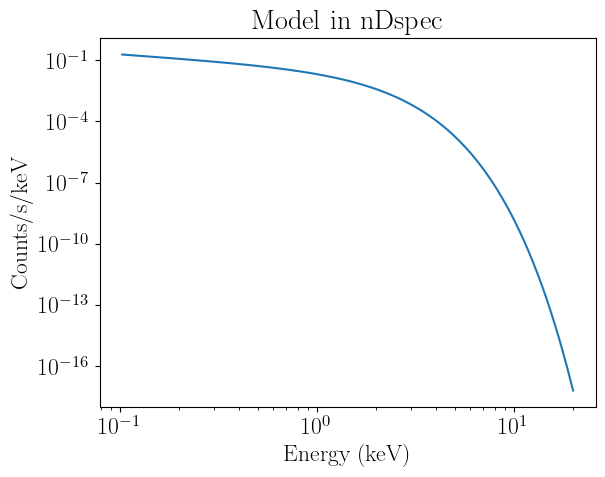

In [6]:
#define the parameters
Tin = 0.5
disknorm = 50
diskpars = np.array([Tin,disknorm])

#now call one of the models and plot it
midpoint = 0.5*(energs[1:]+energs[:-1])

disk = model_library.diskbb(energs,diskpars)

plt.loglog(midpoint,disk)
plt.title("Model in nDspec")
plt.xlabel("Energy (keV)")
plt.ylabel("Counts/s/keV")

It is extremely important to be mindful of the units models are computed in. By default, Xspec functions calculate the flux in units of counts/s, and therefore renormalize by the width of the energy bin. The equivalent in nDspec is:

Text(0, 0.5, 'Counts/s')

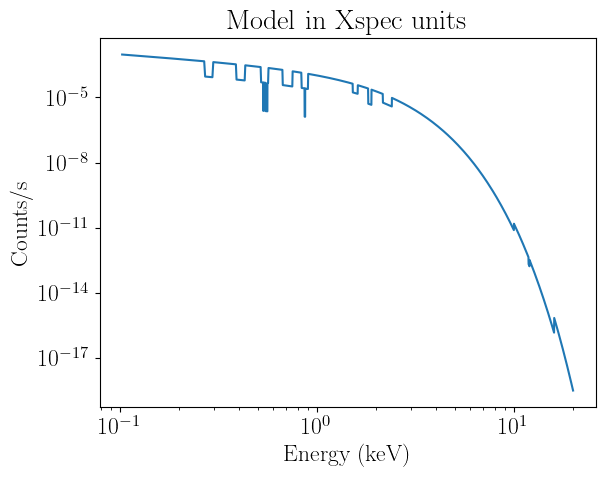

In [7]:
binwidth = nicer_matrix.energ_hi - nicer_matrix.energ_lo

plt.loglog(midpoint,disk*binwidth)
plt.title("Model in Xspec units")
plt.xlabel("Energy (keV)")
plt.ylabel("Counts/s")

These unit conversions are handled automatically under the hood by nDspec, and the computation of folding instrument responses etc is identical. The choice of returning models in units of counts/s/keV is to expose arrays that are easily interpretable (as they lack the narrow features of models renormalized by bin width - compare the first plot in this tutorial with the second).

Now that we have corrected the units of our models, let us include two more components:

tbvabs Version 2.3
Cosmic absorption with grains and H2, modified from
Wilms, Allen, & McCray, 2000, ApJ 542, 914-924
Questions: Joern Wilms
joern.wilms@sternwarte.uni-erlangen.de
joern.wilms@fau.de

http://pulsar.sternwarte.uni-erlangen.de/wilms/research/tbabs/

PLEASE NOTICE:
To get the model described by the above paper
you will also have to set the abundances:
   abund wilm

Note that this routine ignores the current cross section setting
as it always HAS to use the Verner cross sections as a baseline.


(0.0015, 0.05)

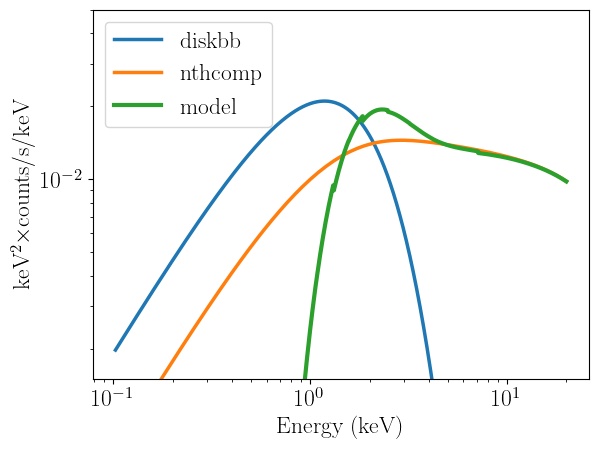

In [8]:
nH = 1
abspars = np.array([nH])

Gamma = 2.1
kT_e = 10.
kT_bb = Tin
inp_type = 1
Redshift = 0
compnorm = 0.01
nthcomppars = np.array([Gamma,kT_e,kT_bb,inp_type,Redshift,compnorm])

absorption = model_library.tbabs(energs,abspars)
compton = model_library.nthcomp(energs,nthcomppars)

model = absorption*(compton+disk)

#let us also convert the y axis to flux
plt.loglog(midpoint,disk*midpoint**2,label="diskbb",lw=2.5)
plt.loglog(midpoint,compton*midpoint**2,label="nthcomp",lw=2.5)
plt.loglog(midpoint,model*midpoint**2,label="model",lw=3)
plt.xlabel("Energy (keV)")
plt.ylabel("keV$^{2}\\times$counts/s/keV")
plt.legend(loc="upper left")
plt.ylim([1.5e-3,0.05])

## Handling convolution models

Finally, we can try to include a convolution model like ```reflect```. This case is more complex, for two reasons. First,we also need to provide the starting array to be convolved with the model. Second, in order to avoid numerical issues (particularly near the bondary of the energy grid), we actually need to use a wider energy grid, and then interpolate back to the NICER grid after performing the convolution. We will use ```scipy``` for this. 

Compton reflection. See help for details.
If you use results of this model in a paper,
please refer to Magdziarz & Zdziarski 1995 MNRAS, 273, 837


(0.0015, 0.05)

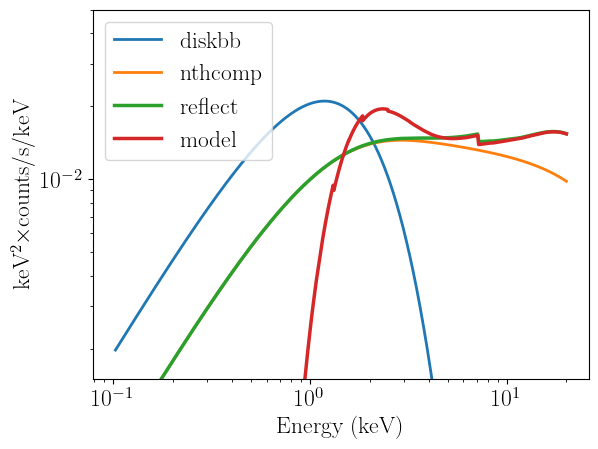

In [9]:
from scipy.interpolate import interp1d

energs_extend = np.logspace(-2.,3,1000)
energs_extend = np.array(energs_extend)
binwidth_extend = np.diff(energs_extend)
compton_extend = model_library.nthcomp(energs_extend,nthcomppars)

rel_refl = 1
Redshift = 0
abund = 1
Fe_abund = 1
cosIncl = 0.95   #the reflect model only allows cosIncl in [0.05, 0.95]

refpars = np.array([rel_refl,Redshift,abund,Fe_abund,cosIncl])

reflection_extend = model_library.reflect(energs_extend,refpars,compton_extend)

#now define an interpolation object and go back to the NICER energy grid
energs_extend_center = 0.5*(energs_extend[1:]+energs_extend[:-1])
array_interp = interp1d(energs_extend_center,reflection_extend,fill_value='extrapolate')        
reflection = array_interp(midpoint)

#finally, put all the model components together
model = absorption*(reflection+disk)

plt.loglog(midpoint,disk*midpoint**2,label="diskbb",lw=2)
plt.loglog(midpoint,compton*midpoint**2,label="nthcomp",lw=2)
plt.loglog(midpoint,reflection*midpoint**2,label="reflect",lw=2.5)
plt.loglog(midpoint,model*midpoint**2,label="model",lw=2.5)
plt.xlabel("Energy (keV)")
plt.ylabel("keV$^{2}\\times$counts/s/keV")
plt.legend(loc="upper left")
plt.ylim([1.5e-3,0.05])

## User-defined models

Users can also load user-defined libraries and models other than those built by a HEASOFT installation, provided that they use the same input and output format. In this example, we will use the ```add_library``` method to load and run the [reltrans](https://github.com/reltrans/reltrans) X-ray reverberation model. Users need to specify both the path to the library they want to load, and that to the corresponding ```lmodel.dat``` file containing the model definitions and parameters. Once a library is added, its models are added with ```add_models``` exactly like the Xspec ones.

Reltrans is compiled with `make` (see its README), which builds `build/lib/libreltrans.so` (`.dylib` on macOS); the model also needs the `RELTRANS_TABLES` environment variable to point to its xillver tables.

In [10]:
#define the path to the library and lmodel file to be loaded: change these
#to wherever reltrans is installed on your machine
ext = 'dylib' if sys.platform == 'darwin' else 'so'
reltranspath = os.path.expanduser('~/projects/reltrans_all/reltrans/build/lib/libreltrans.' + ext)
reltransfile = os.path.expanduser('~/projects/reltrans_all/reltrans/xspec/lmodel_reltrans.dat')

model_library.add_library(reltranspath, reltransfile)
model_library.add_models("reltransDCp")
model_library.print_model_info()


Initialized Xspec models:
diskbb:
  type: add
  library: xspec
  parameters:
    Tin: value: 1.0, min: 0.0, max: 1000.0, unit: keV
    norm: value: 1.0, min: 0.0, max: 1e+20, unit: n/a

tbabs:
  type: mul
  library: xspec
  parameters:
    nH: value: 1.0, min: 0.0, max: 1000000.0, unit: 10^22

nthcomp:
  type: add
  library: xspec
  parameters:
    Gamma: value: 1.7, min: 1.001, max: 10.0, unit: n/a
    kT_e: value: 100.0, min: 1.0, max: 1000.0, unit: keV
    kT_bb: value: 0.1, min: 0.001, max: 10.0, unit: keV
    inp_type: value: 0.0, min: 0.0, max: 1.0, unit: 0/1
    Redshift: value: 0.0, min: -0.999, max: 10.0, unit: n/a
    norm: value: 1.0, min: 0.0, max: 1e+20, unit: n/a

reflect:
  type: con
  library: xspec
  parameters:
    rel_refl: value: 0.0, min: -1.0, max: 1000000.0, unit: n/a
    Redshift: value: 0.0, min: -0.999, max: 10.0, unit: n/a
    abund: value: 1.0, min: 0.0, max: 1000000.0, unit: n/a
    Fe_abund: value: 1.0, min: 0.0, max: 1000000.0, unit: n/a
    cosIncl: val

We can now define a set of parameters and evaluate the model identically to before:

 ----------------------------------------------------
  *** ENVIRONMENT VARIABLES *** 

 RADIAL ZONES          20
 ANGLE ZONES           1
 A_DENSITY:           0 Density profile is constant
 VERBOSE is            0
 REFVAR is            1
 IONVAR is            1
 ----------------------------------------------------
 ----------------------------------------------------
 This is RELTRANS 2.3.2: a transfer function model for
 X-ray reverberation mapping.
 Please cite Ingram et al (2019) MNRAS 488 p324-347, 
 Mastroserio et al (2021) MNRAS 507 p55-73, and 
 Lucchini et al (2023) arXiv 230505039L.
 ----------------------------------------------------


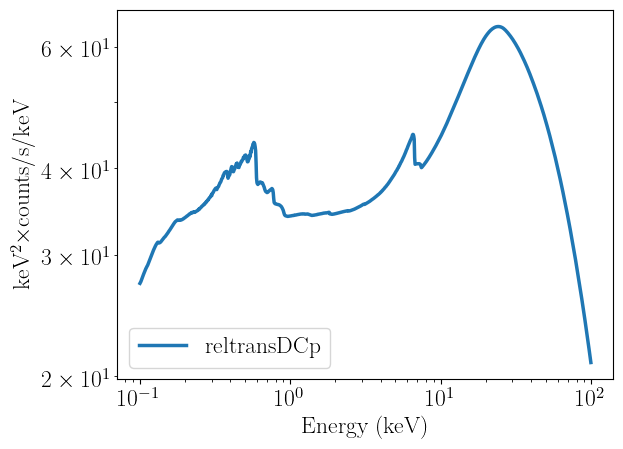

In [11]:
h = 6
a = 0.998
inc = 30
rin = -1
rout = 1e3
z = 0
Gamma = 2
logxi = 3
Afe = 1
logNe = 15
kTe = 60
nH = 0
boost = 1
Mass = 4.6e7
fmin = 0     #fmin = fmax = 0 returns the time-averaged spectrum
fmax = 0
ReIm = -1
phiA = 0
phiAB = 0
g = 0
RESP = 1
norm = 1

params_reltrans = np.array([h,a,inc,rin,rout,z,Gamma,logxi,Afe,logNe,kTe,nH,boost,Mass,
                            fmin,fmax,ReIm,phiA,phiAB,g,RESP,norm])

energs = np.logspace(-1.,2,1000)
binwidth = np.diff(energs)
midpoint = 0.5*(energs[1:]+energs[:-1])

reltrans_flux = model_library.reltransdcp(energs,params_reltrans)

plt.figure(1)
plt.loglog(midpoint,reltrans_flux*midpoint**2,lw=2.5,label="reltransDCp")
plt.xlabel("Energy (keV)")
plt.ylabel("keV$^{2}\\times$counts/s/keV")
plt.legend(loc="lower left")

## Listing models and checking parameters

Each library loaded in a `ModelInterface` has a name: the built-in Xspec models are in the `"xspec"` library, and libraries added with `add_library` are named after their file (`libreltrans.so` becomes `"reltrans"`), unless a different name is passed with `add_library(..., name=...)`. The `available_models` method lists the models that can be added, optionally for a single library, and `check_models` reports any model listed in a model file whose routine cannot be found in its library (an empty dictionary means everything is in place):

In [12]:
#models defined in the reltrans library
print(sorted(model_library.available_models("reltrans")))

#models listed in a model file but missing from its library
print(model_library.check_models())

['reltransdcp', 'reltranspl', 'reltransx', 'rtdist', 'rtdistx', 'rtransdbl', 'simrelt', 'simrtdbl', 'simrtdist']
{}


If two loaded libraries define a model with the same name (for example a local build of an Xspec model), `add_models` does not guess which one to use: it raises an error, and the library has to be chosen explicitly:

```python
model_library.add_models("gaussian", library="xspec")
```

Finally, every model call checks that the right number of parameters is passed, and that each one is within the hard limits given in the model file. If not, a `ParameterException` is raised, with a message naming the offending parameter:

In [13]:
try:
    model_library.tbabs(energs, [-1.0])
except XSModels.ParameterException as error:
    print(error)

tbabs: parameter nH = -1.0 is outside its limits [0.0, 1000000.0]


## Setting up XspecInterface calls for a nDspec fitter object

Finally, we would like to prepare a function that can be passed to an nDspec fitter object for our inference. Doing this is as simple as wrapping the function call in a LMFit Model object, taking care to use a naming convention consistent with nDspec (ie, the input energy array needs to be called "ear"):

In [14]:
from lmfit import Model as LM_Model

def ndspec_reltrans(ear,h,a,inc,rin,rout,z,Gamma,logxi,Afe,logNe,kTe,nH,boost,Mass,
                    fmin,fmax,ReIm,phiA,phiAB,g,RESP,norm):
    par_array = np.array([h,a,inc,rin,rout,z,Gamma,logxi,Afe,logNe,kTe,nH,boost,Mass,
                          fmin,fmax,ReIm,phiA,phiAB,g,RESP,norm])
    model = model_library.reltransdcp(ear,par_array)
    return model

reflection_model = LM_Model(ndspec_reltrans)

## How nDspec finds and calls Xspec models

Every model in Xspec is described in a `model.dat` file (or a local `lmodel.dat`), where each entry starts with a header line:

```
<name>  <npars>  <elow>  <ehigh>  <function>  <type>  <errflag> ...
```

The *model name* (the first field, e.g. `gaussian`) is what you use in nDspec. The *function* field (e.g. `C_gaussianLine`) is the compiled routine that actually gets called, and its **prefix tells you the language and precision** of that routine:

| Prefix | Language / precision |
|---|---|
| (none) | Fortran, single precision |
| `F_` | Fortran, double precision |
| `c_` | C |
| `C_` | C++ |

This is described in the Xspec manual [("Writing a new model function")](https://heasarc.gsfc.nasa.gov/docs/software/xspec/manual/node400.html). nDspec reads this prefix from the model file and uses it to call each routine correctly through xspectrampoline, so `ModelInterface` handles Fortran, C and C++ models alike, both for the Xspec library and for any library added with `add_library`.